In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from tqdm import trange

from dv_score import io, util
from dv_score.viz import viz, moe_style_context, bulb

In [3]:
sns.set_theme(font_scale=1, style="ticks", palette="tab10", context="talk")

# Compare DV scores to glomerular location
* Spatial transcriptomics data from [Klimpert, Kollo et al. bioRxiv](https://doi.org/10.1101/2025.02.19.639192).

In [4]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.neighbors import NearestNeighbors

In [5]:
domain_colors = bulb.bulb_colors()
DOMAINS, DOMAIN_NAMES, new_old_map = bulb.domains()
GEP3 = ["DV", "AP", "ES"]
GEP3_qt = [g + "_qt" for g in GEP3]
rc_cols = ["x_flipped", "y", "z"]

In [6]:
df_geom_dv = io.load_glomeruli()
is_med = df_geom_dv.domain == "ventro-medial"
df_med = df_geom_dv[is_med]
df_lat = df_geom_dv[~is_med]

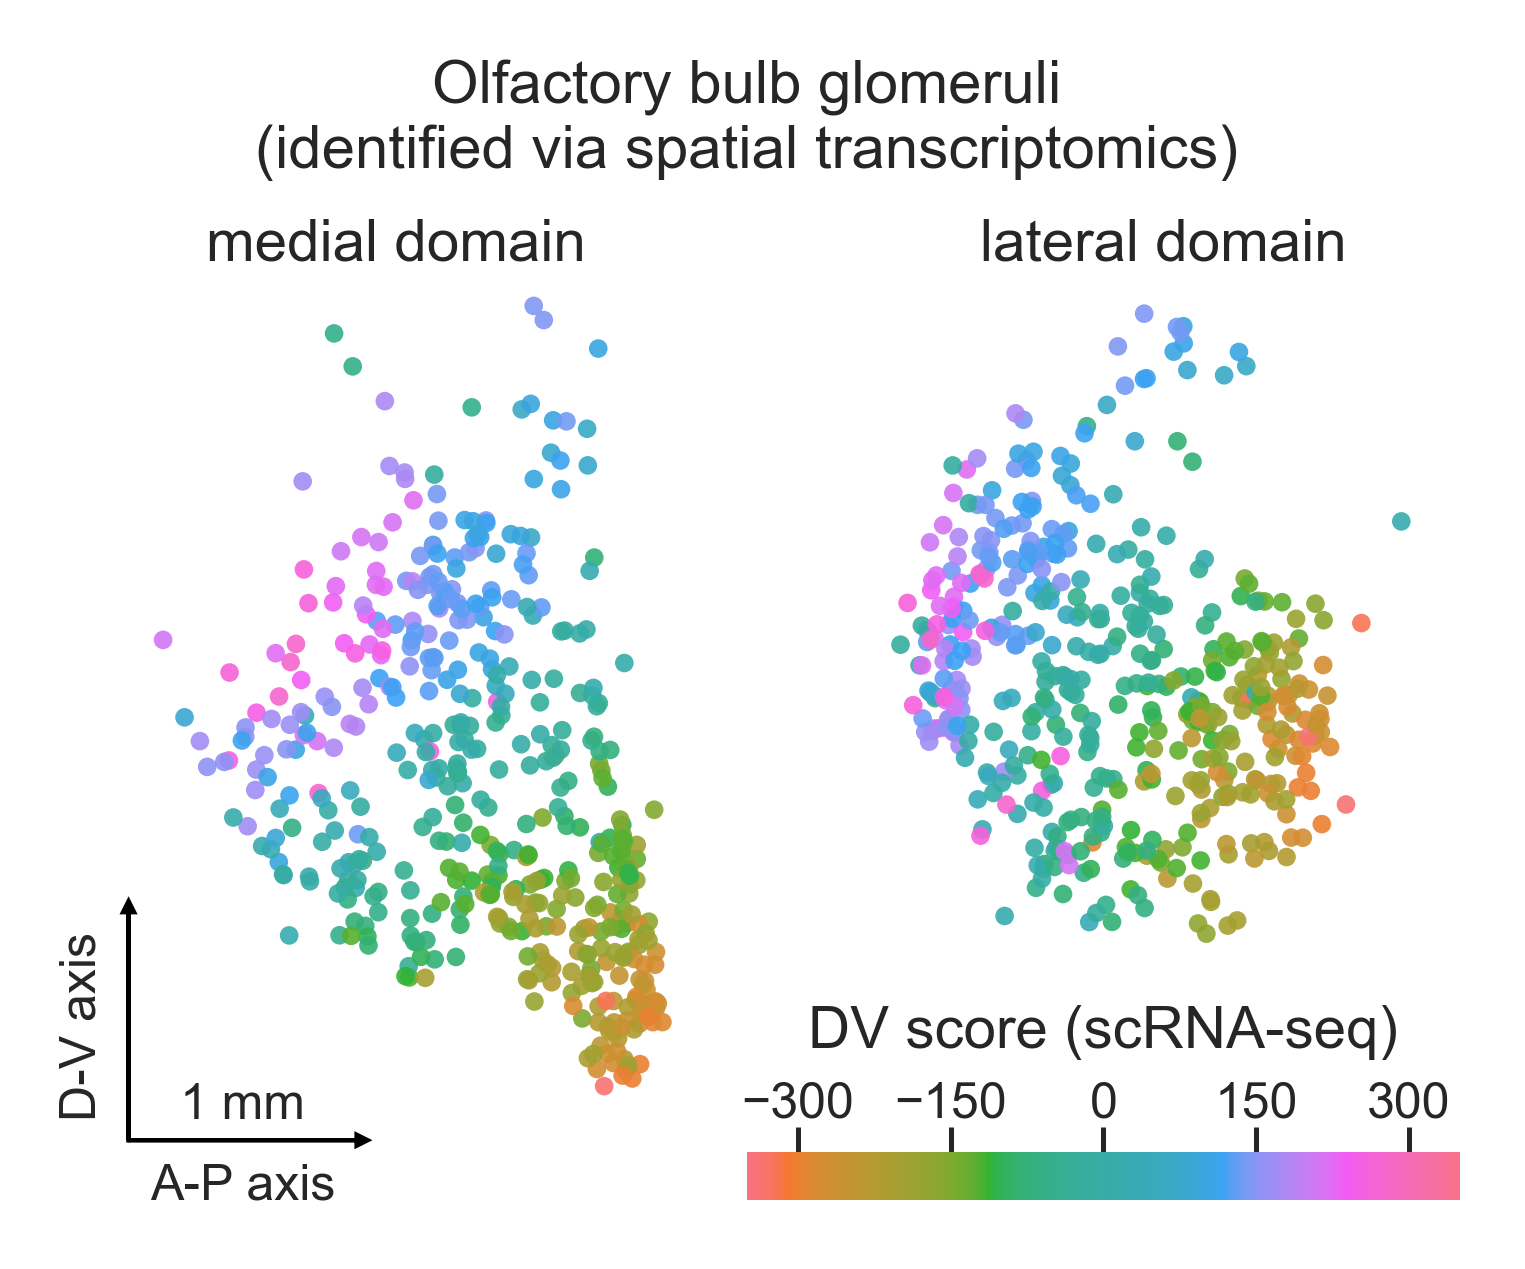

In [7]:
dv_kwargs = dict(
    cmap=viz.dv_cmap(),
    s=5,
    lw=0,
    vmin=-350,
    vmax=350,
    alpha=0.9,
)

with moe_style_context():
    fig, axes = bulb.plot_c_col(df_geom_dv, dv_kwargs, c_col="DV");
    fig.suptitle("Olfactory bulb glomeruli\n(identified via spatial transcriptomics)", y=1.05)

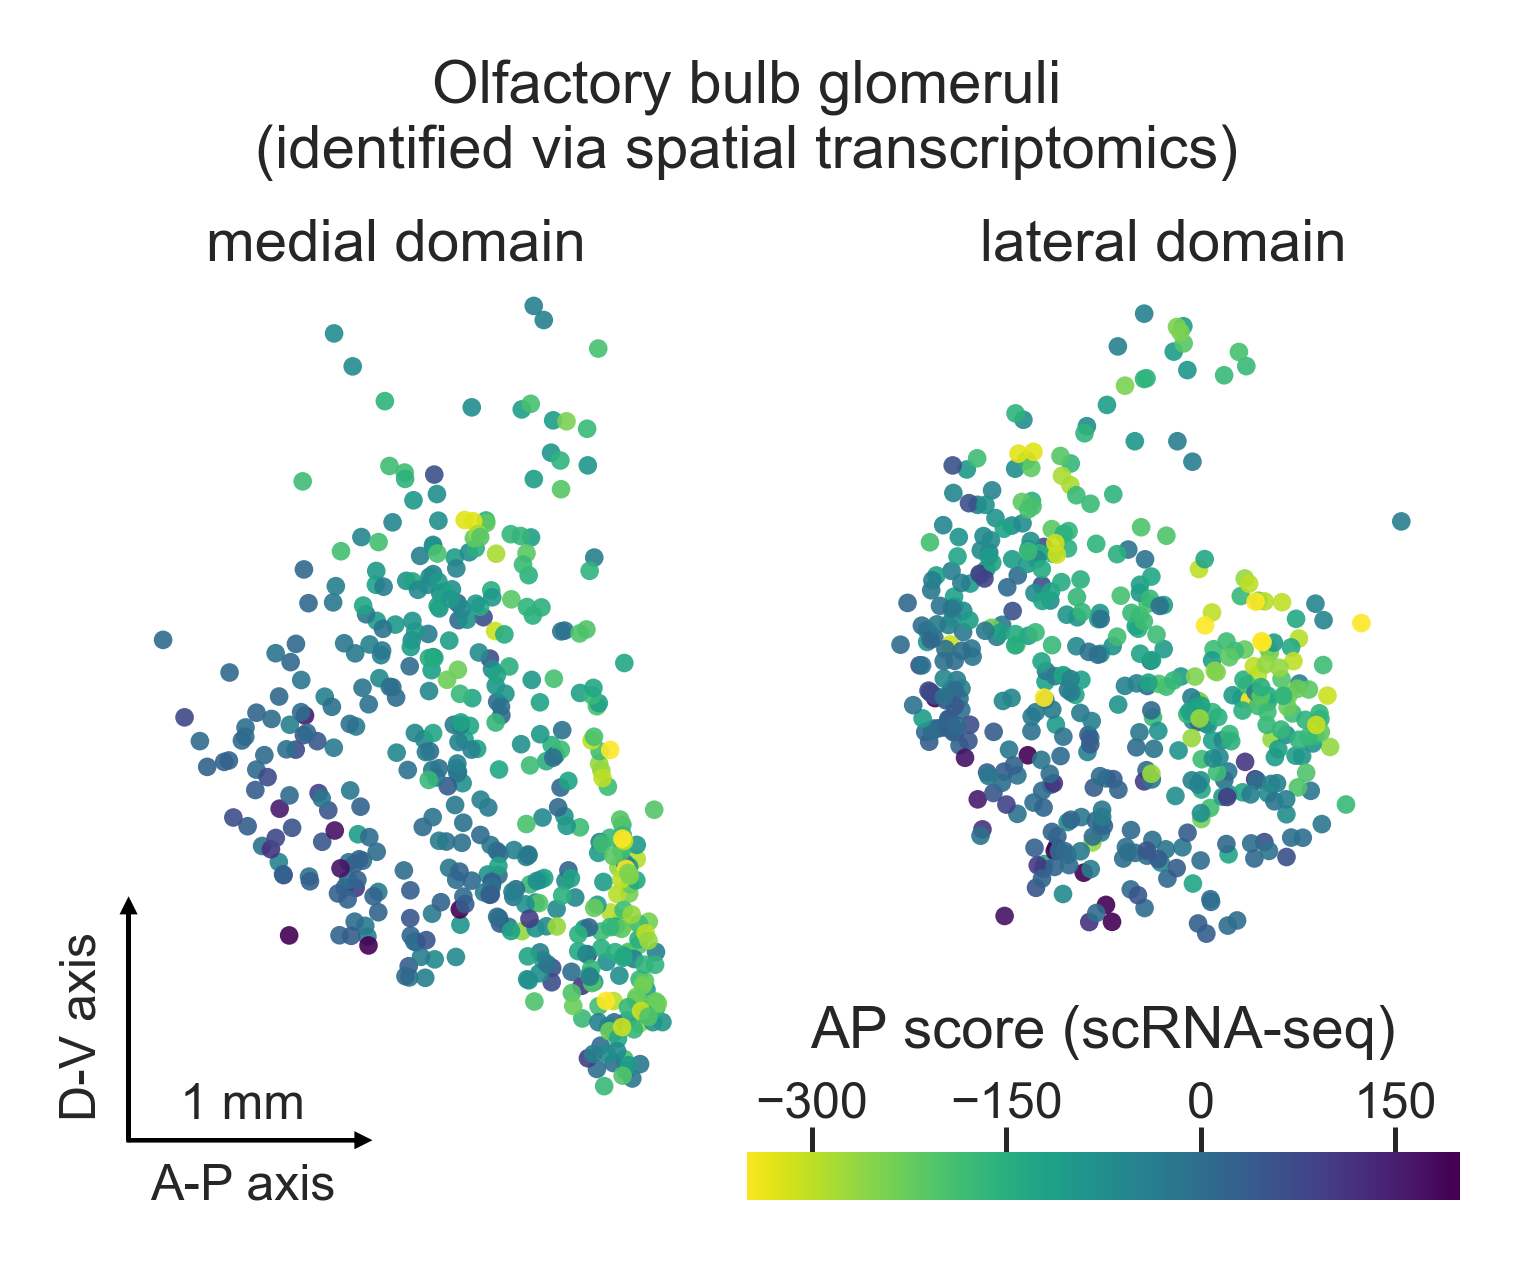

In [8]:
ap_kwargs = dict(
        cmap="viridis_r",
        s=5,
        lw=0,
        vmin=-350,
        vmax=200,
        alpha=0.9,
    )


with moe_style_context():
    fig, axes = bulb.plot_c_col(df_geom_dv, ap_kwargs, c_col="AP")
    fig.suptitle("Olfactory bulb glomeruli\n(identified via spatial transcriptomics)", y=1.05)

## Mean GEP distance for neighboring glomeruli 

In [9]:
df_median = df_geom_dv.groupby(["domain", "top_Olfr"], as_index=False).median(
    numeric_only=True
)

In [10]:
max_n = 200
knn = NearestNeighbors(n_neighbors=max_n).fit(df_median[rc_cols])
y_dv_med = df_median[GEP3_qt].values
xn = np.arange(max_n)
neighbor_idx = knn.kneighbors(return_distance=False)

deltas = np.abs(y_dv_med[neighbor_idx] - y_dv_med[:, None])
med_mat = np.zeros_like(deltas)

for i in range(max_n):
    med_mat[:, i] = deltas[:, :(i+1)].mean(1)
ci = util.get_ci_mat_vectorized(med_mat)

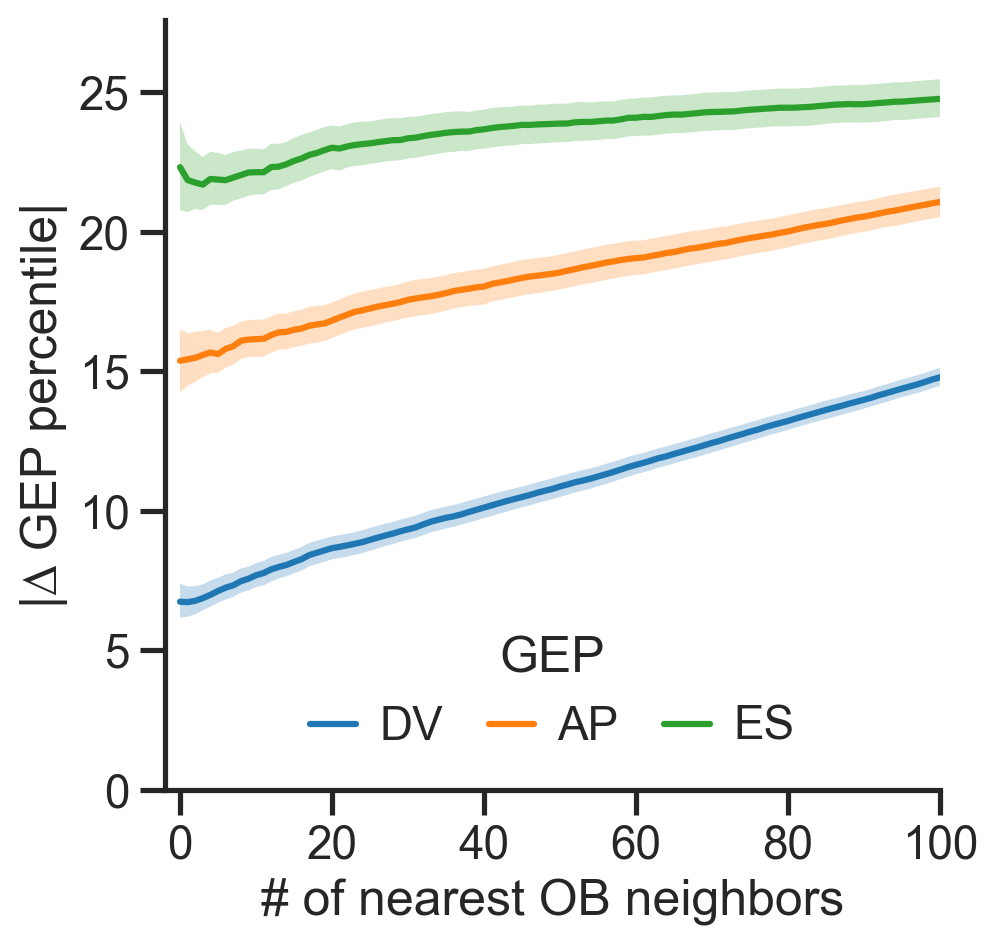

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
for i, g in enumerate(GEP3):
    ax.plot(xn, med_mat[:, :, i].mean(0), label=g)
    ax.fill_between(xn, *ci[:, :, i], alpha=0.25, lw=0)
ax.set_xlim(-2, 100)
sns.despine()
ax.set_ylim(0, None)
ax.set_xlabel("# of nearest OB neighbors")
ax.set_ylabel("|∆ GEP percentile|")
leg = ax.legend(
    title="GEP",
    handlelength=1,
    ncols=3,
    columnspacing=1,
    handletextpad=0.5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    frameon=False,
)
ax.set_ylim(0, None)
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(20))

## Predict GEPs from glomerular positions via linear regression

* For predicting positions from GEPs see the script [run_OB_regression.py](../scripts/analysis/run_OB_regression.py).

In [12]:

steps = [("scale", StandardScaler()), ("mdl", SVR(C=150))]
pipe = Pipeline(steps)

In [13]:
def do_lr(df, n_restart=100, col="DV", rc_cols=rc_cols):
    df_plot = df.groupby("top_Olfr")[rc_cols + [col]].median()
    y = df_plot[col]
    corrs = np.zeros((n_restart, 2))
    for i in trange(n_restart, ncols=80):
        cv = KFold(n_splits=5, random_state=i, shuffle=True)
        preds = cross_val_predict(pipe, df_plot[rc_cols], y, cv=cv)
        corrs[i, 0] = stats.spearmanr(y, preds).correlation
        y_shuff = np.random.permutation(y)
        pred2 = cross_val_predict(pipe, df_plot[rc_cols], y, cv=cv)
        corrs[i, 1] = stats.spearmanr(y_shuff, pred2).correlation
    corrs = pd.DataFrame(corrs, columns=["obs", "shuff"])
    return  corrs

In [14]:
corr_dict = {}
for g in GEP3:
    print(g)
    for k, df in df_geom_dv.groupby("domain"):
        corr_dict[(g, k)] = do_lr(df, col=g)
df_lr_corr = pd.concat(corr_dict).reset_index()

DV


100%|█████████████████████████████████████████| 100/100 [00:11<00:00,  8.48it/s]


AP


100%|█████████████████████████████████████████| 100/100 [00:11<00:00,  8.38it/s]


ES


100%|█████████████████████████████████████████| 100/100 [00:09<00:00, 10.32it/s]


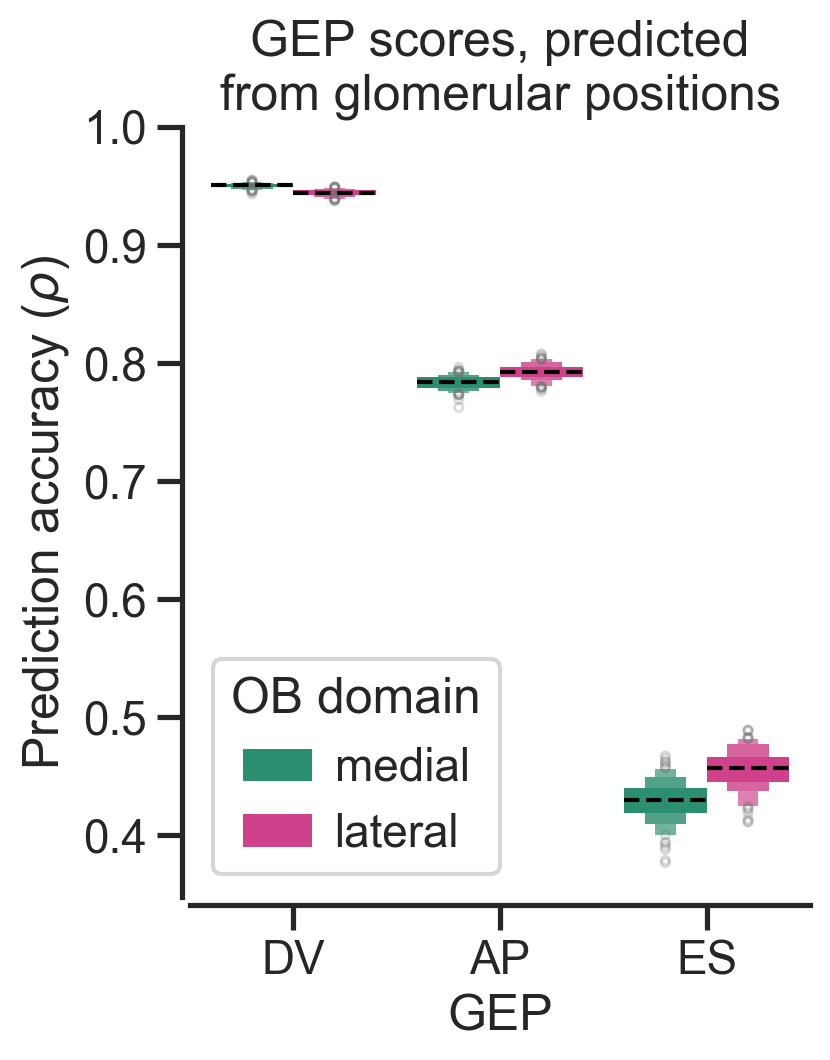

In [15]:
fig, ax = plt.subplots(figsize=(4, 5))

sns.boxenplot(
    data=df_lr_corr,
    ax=ax,
    palette=domain_colors,
    x="level_0",
    y="obs",
    hue="level_1",
    hue_order=DOMAINS,
    flier_kws={"s": 36, "alpha": 0.25, "lw": 1, "marker": "."},
    
)
viz.update_boxen(ax, remove_fliers=False, lw=1.5)
ax.set_ylabel(r"Prediction accuracy ($\rho$)")
sns.despine()
ax.set_xlabel("GEP")
ax.set_title("GEP scores, predicted\nfrom glomerular positions")
sns.despine(offset=3)
ax.set_ylim(None, 1)

handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(
    handles,
    DOMAIN_NAMES,
    title="OB domain",
    loc="lower left",
    bbox_to_anchor=(-0., 0),
    handlelength=1.5,
    handletextpad=0.5,
)
viz.remove_leg_border(leg)